# **Real-ESRNet avec 🔥 Pytorch**

# I. Introduction

Real-ESRGAN constitue l'un des modèles de super-résolution (SR) les plus performants actuellement. Sa rapidité et sa capacité à générer des textures plus réalistes en font un modèle de choix dans les tâches d'augmentation de résolution d'images et de vidéos en temps réel.

Dans ce notebook, nous créerons notre propre modèle de super-résolution en utilisant l'architecture du générateur du Real-ESRGAN, c'est-à-dire Real-ESRNet. Pour ce faire, nous définirons en premier lieu les dégradations d'images haute résolution (HR) que nous appliquerons sur l'ensemble d'entraînements. En deuxième lieu, nous créerons l'architecture du Real-ESRNet et nous entraînerons le modèle. En troisième lieu, nous essaierons le modèle sur des images de test différentes de l'ensemble d'entraînement.

Voici un lien pour voir l'article :
https://arxiv.org/abs/2107.10833v2

# II. Imports et configurations




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/mlomnitz/DiffJPEG

Cloning into 'DiffJPEG'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 60 (delta 2), reused 0 (delta 0), pack-reused 50 (from 1)
Receiving objects: 100% (60/60), 520.07 KiB | 2.51 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [ ]:
import shutil

In [ ]:
import torch
from torchvision import transforms
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.transforms import v2
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.init as init
import torchvision.utils as vutils

In [ ]:
from glob import glob
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
import sys

path = '/content/DiffJPEG'

if path not in sys.path:
    sys.path.append(path)

from DiffJPEG import DiffJPEG

In [ ]:
from scipy import special
import random
import math

In [ ]:
from degradations import create_LR_tensor_image

In [ ]:
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Entraînement sur {device} device.")

Entraînement sur cuda device.


In [ ]:
BATCH_SIZE = 20

# III. Chargement et préparation des données

## III.1. Chargement et préparation des images HR

### III.1.1. Description des données

Notre ensemble de données contient des images libres de droit, téléchargées sur internet, que nous avons découpées en patchs de taille 256 x 256 px.

Voici des extraits de ces images :

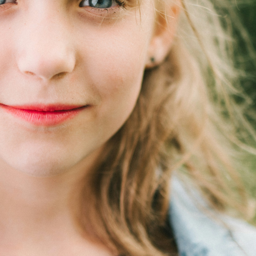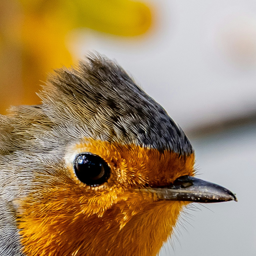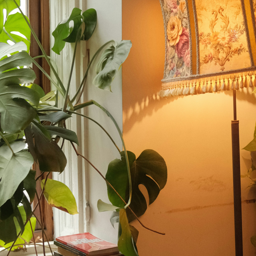

### III.1.2. Décompression des images

Nous allons d'abord décompresser les données vers le disque dur de Colab pour faciliter la lecture des données.

In [ ]:
shutil.unpack_archive('/content/drive/MyDrive/Colab Notebooks/data/SISR/HR_images.zip', '/content/')

In [ ]:
paths = glob('/content/HR_images/*')
print(f"Nombre total d'images : {len(paths)}")

Nombre total d'images : 6130


### III.1.3. Conversion des images

Certaines images sont encore en mode RGBA, c'est-à-dire qu'elles contiennent 4 canaux. Ce qui n'est pas compatible avec l'entrée du réseau que nous allons créer. Donc, nous les convertissons en mode RGB qui contient exactement 3 canaux.

In [ ]:
nbr = 0
for file in paths:
  with Image.open(file) as hr_image:
    if(len(hr_image.getbands()) != 3):
      hr_image = hr_image.convert('RGB')
      file_name = '/content/HR_images/' + file[19:]

      hr_image.save(file_name)

      nbr += 1

print(f"Nombre d'images converties en mode RGB : {nbr}")

Nombre d'images converties en mode RGB : 2


### III.1.4. Augmentation des données

Nous n'avons pas beaucoup de données, alors pour mieux entraîner le modèle nous allons faire une augmentation de données. Les types d'augmentations de données que nous appliquerons sont : une rotation aléatoire de 90° ou une symétrie horizontale ou verticale.

Les images à appliquer la transformation sont 3870 images tirées au hasard dans l'ensemble de données.

In [ ]:
n = random.sample(range(0, len(paths)), k=3870)

In [ ]:
for i in tqdm(n, desc="Augmentation de données"):
  with Image.open(paths[i]) as hr_image:
    n = random.randint(1, 4)
    if(n == 1):
      out = hr_image.transpose(Image.FLIP_LEFT_RIGHT)
    if(n == 2):
      out = hr_image.transpose(Image.FLIP_TOP_BOTTOM)
    if(n == 3):
      out = hr_image.rotate(90)
    if(n == 4):
      out = hr_image.rotate(-90)

    out.save('/content/HR_images/' + paths[i][19:-4] + '_.png')

Augmentation de données: 100%|██████████| 3870/3870 [01:48<00:00, 35.66it/s]


In [ ]:
print(f"Le nombre total d'images après augmentation de données est : {len(glob('/content/HR_images/*'))} images.")

Le nombre total d'images après augmentation de données est : 10000 images.


## III.2. Préparation des images LR

### III.1.1. Dégradation des images HR

Dans ce notebook, nous utiliserons la dégradation du second ordre, comme le montre la figure suivante :

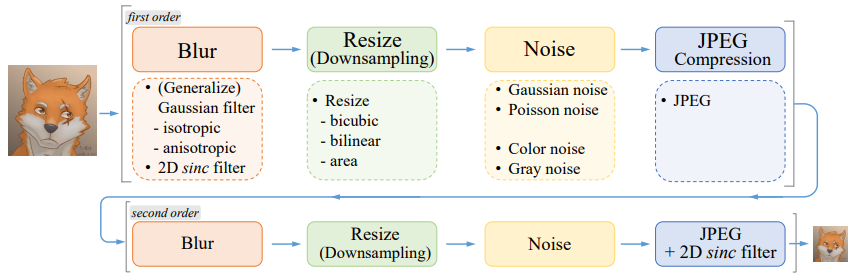

In [ ]:
!mkdir '/content/LR_images'

In [ ]:
transform = transforms.ToTensor()

Voici les paramètres de la dégradation. Le facteur de redimensionnement est 1 ou 2 ou 4.

In [ ]:
blur_sigma_range = [[0.2, 3], [0.2, 1.5]]
noise_sigma_range = [[0.001, 0.1], [0.01, 0.05]]
noise_scale_range_ = [[30, 50], [30, 45]]
resize_factor_choices = [[[1, 1], [1, 1]], [[2, 1], [1, 2]], [[1, 4], [2, 2], [4, 1]]]
omega_c = np.pi/3

Nous appliquons la même dégradation sur 5 images consécutives.

In [ ]:
paths = glob('/content/HR_images/*')
random.shuffle(paths)
k = 0
resize_factor_ = []
for i in tqdm(range(0, len(paths) - 5, 5)):
  if(i % BATCH_SIZE == 0):
    if(k == len(resize_factor_choices)):
      k = 0
    resize_factor_ = resize_factor_choices[k]
    k += 1
  resize_factor = resize_factor_[random.randint(0, len(resize_factor_) -1)]
  batch_paths = paths[i:i+5]
  batch_y = []
  batch_x = []
  for file in batch_paths:
    with Image.open(file) as hr_image:
      tensor_hr = transform(hr_image).to(device)
      batch_y.append(tensor_hr)

  batch_y = torch.stack(batch_y).to(device)
  tensor_lr = create_LR_tensor_image(batch_y, blur_sigma_range, noise_sigma_range, noise_scale_range_, omega_c, resize_factor, d=2)

  for j in range(tensor_lr.size(0)):  # Boucle sur le Batch
    chemin_indiv = f'/content/LR_images/{paths[i + j][19:]}'
    vutils.save_image(tensor_lr[j], chemin_indiv, normalize=True)

100%|██████████| 1999/1999 [11:38<00:00,  2.86it/s]


### III.1.2. Aperçu des images dégradées

Voici une illustration des images dégradées.

In [ ]:
img1 = Image.open('/content/LR_images/' + paths[3][19:])

In [ ]:
img2 = Image.open('/content/LR_images/' + paths[870][19:])

In [ ]:
img3 = Image.open('/content/LR_images/' + paths[9700][19:])

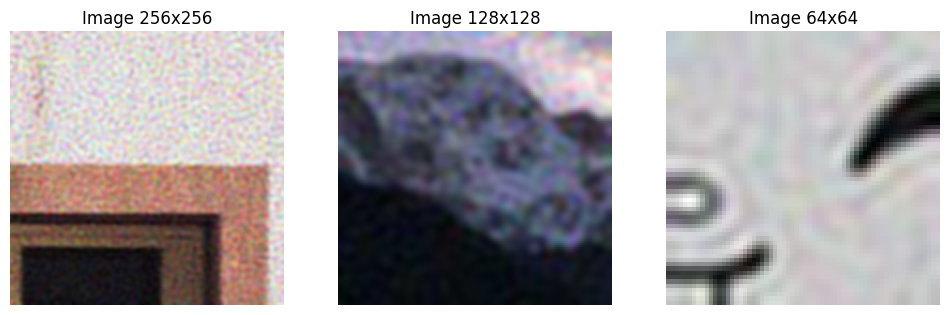

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Image 256x256')
plt.imshow(img1)
plt.axis('off')
plt.subplot(132)
plt.title('Image 128x128')
plt.imshow(img2)
plt.axis('off')
plt.subplot(133)
plt.title('Image 64x64')
plt.imshow(img3)
plt.axis('off')
plt.show()

# IV. Architecture du réseau

### IV.1. RRDB

Définissons d'abord l'architecture du RRDB.

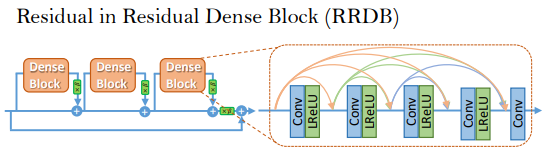

In [ ]:
class Dense_block(nn.Module):
  def __init__(self):
    super(Dense_block, self).__init__()
    self.blocks = nn.ModuleList()
    for i in range(4):
      self.blocks.append(
          nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding='same'),
            nn.LeakyReLU(0.2)
          )
      )

    self.final_conv = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding='same')

    self.small_initialization(0.1)

  def small_initialization(self, factor):
    for m in self.modules():
      if isinstance(m, (nn.Conv2d)):
        init.kaiming_normal_(m.weight, a=0.2, mode='fan_in', nonlinearity='leaky_relu')
        m.weight.data.mul_(factor)
        if m.bias is not None:
          init.constant_(m.bias, 0)
          m.bias.data.mul_(factor)

  def sum(self, list_):
    sum = list_[0]
    for element in list_[1:]:
      sum += element
    return sum

  def forward(self, input_img):
    input = [input_img]

    for block in self.blocks:
      n = self.sum(input)
      n = block(n)
      input.append(n.clone().detach())

    del(input[-2])

    n = self.sum(input)

    return self.final_conv(n)

In [ ]:
class RRDB(nn.Module):
  def __init__(self):
    super(RRDB, self).__init__()
    self.dense_blocks = nn.ModuleList()
    for i in range(4):
      self.dense_blocks.append(Dense_block())

  def forward(self, input_img):
    n = input_img
    for block in self.dense_blocks:
      n = block(n) * 0.2 + n

    return n * 0.2 + input_img

## IV.2. Real-ESRNet

Voici l'architecture du Real-ESRNet :

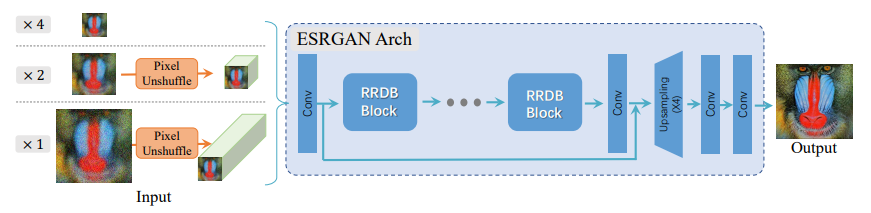

In [ ]:
class Real_ESRNet(nn.Module):
  def __init__(self, rrdb_number):
    super(Real_ESRNet, self).__init__()
    self.initial_conv_1 = nn.Conv2d(3, 64, kernel_size=9, stride=1, padding='same')
    self.initial_conv_2 = nn.Conv2d(12, 64, kernel_size=9, stride=1, padding='same')
    self.initial_conv_3 = nn.Conv2d(48, 64, kernel_size=9, stride=1, padding='same')

    self.rrdb_blocks = nn.ModuleList()
    for i in range(rrdb_number):
      self.rrdb_blocks.append(RRDB())

    self.conv = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding='same')

    self.upsample_block = nn.Sequential(
      nn.Conv2d(64, 256, kernel_size=3, stride=1, padding='same'),
      nn.PixelShuffle(2),
      nn.PReLU(num_parameters=64),
      nn.Conv2d(64, 256, kernel_size=3, stride=1, padding='same'),
      nn.PixelShuffle(2),
      nn.PReLU(num_parameters=64)
    )

    self.final_conv = nn.Sequential(
      nn.Conv2d(64, 64, kernel_size=3, stride=1, padding='same'),
      nn.Conv2d(64, 3, kernel_size=9, stride=1, padding='same')
    )

    self.unshuffle2 = nn.PixelUnshuffle(2)
    self.unshuffle4 = nn.PixelUnshuffle(4)

  def forward(self, input_img, scale):
    if(scale == 4):
      n = self.initial_conv_1(input_img)
    elif(scale == 2):
      n = self.initial_conv_2(self.unshuffle2(input_img))
    elif(scale == 1):
      n = self.initial_conv_3(self.unshuffle4(input_img))

    temp = n

    for block in self.rrdb_blocks:
      n = block(n)

    n = self.conv(n) + temp

    n = self.upsample_block(n)

    return self.final_conv(n)

# V. Entraînements et tests du modèle

## V.1. Entraînements

Avant l'entraînement, nous initialisons d'abord le modèle, l'erreur et l'optimiseur. Nous utilisons un Real-ESRNet avec 4 blocs RRDB.

In [ ]:
generator = Real_ESRNet(4).to(device)
content_criterion = nn.L1Loss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.9, 0.999))
k = 0

Pour continuer un entraînement, nous récupérons l'état du dernier modèle sauvegardé.

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/data/SISR/Real_ESRNet_checkpoint_epoch_300.pth')

generator.load_state_dict(checkpoint['generator_state_dict'])
optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])

k = checkpoint['epoch']

In [ ]:
n_epochs = 400
for epoch in range(k, n_epochs):
  epoch_loss = 0
  for i in tqdm(range(0, len(paths) - BATCH_SIZE, BATCH_SIZE)):
    batch_paths = paths[i:i+BATCH_SIZE]
    batch_y = []
    batch_x = []
    for file in batch_paths:
      with Image.open(file) as hr_image:
        tensor_hr = transform(hr_image).to(device)
        batch_y.append(tensor_hr)

      with Image.open('/content/LR_images/' + file[19:]) as lr_image:
        tensor_lr = transform(lr_image).to(device)
        batch_x.append(tensor_lr)

    batch_y = torch.stack(batch_y).to(device)
    batch_x = torch.stack(batch_x).to(device)

    if(batch_x.shape[2] == 256):
      scale = 1
    if(batch_x.shape[2] == 128):
      scale = 2
    if(batch_x.shape[2] == 64):
      scale = 4

    gen_imgs = generator(batch_x, scale)

    real_esrnet_loss = content_criterion(gen_imgs, batch_y)

    optimizer_G.zero_grad()
    real_esrnet_loss.backward()
    optimizer_G.step()

  if((epoch + 1) % 2 == 0):
    torch.save({
      'epoch': epoch + 1,
      'generator_state_dict': generator.state_dict(),
      'optimizer_G_state_dict': optimizer_G.state_dict(),
    }, f'/content/drive/MyDrive/Colab Notebooks/data/SISR/Real_ESRNet_checkpoint_epoch_{epoch + 1}.pth')

100%|██████████| 499/499 [06:10<00:00,  1.35it/s]


## V.2. Test du modèle

Pour tester le modèle, nous utilisons des images qui n'appartiennent pas à l'ensemble d'entraînement.

Récupérons d'abord le modèle à utiliser.

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/data/SISR/Real_ESRNet_checkpoint_epoch_300.pth')
generator = Real_ESRNet(4).to(device)
generator.load_state_dict(checkpoint['generator_state_dict'])

<All keys matched successfully>

Générons des images avec un facteur d'agrandissement x4.

In [ ]:
transform = transforms.ToTensor()

In [ ]:
lr_img_1 = Image.open('/content/images (2).jfif')

In [ ]:
lr_img_2 = Image.open('/content/images (17).jfif')

In [ ]:
t1 = generator(transform(lr_img_1).unsqueeze(0).to(device), 4)

In [ ]:
t2 = generator(transform(lr_img_2).unsqueeze(0).to(device), 4)

Visualisons les résultats.

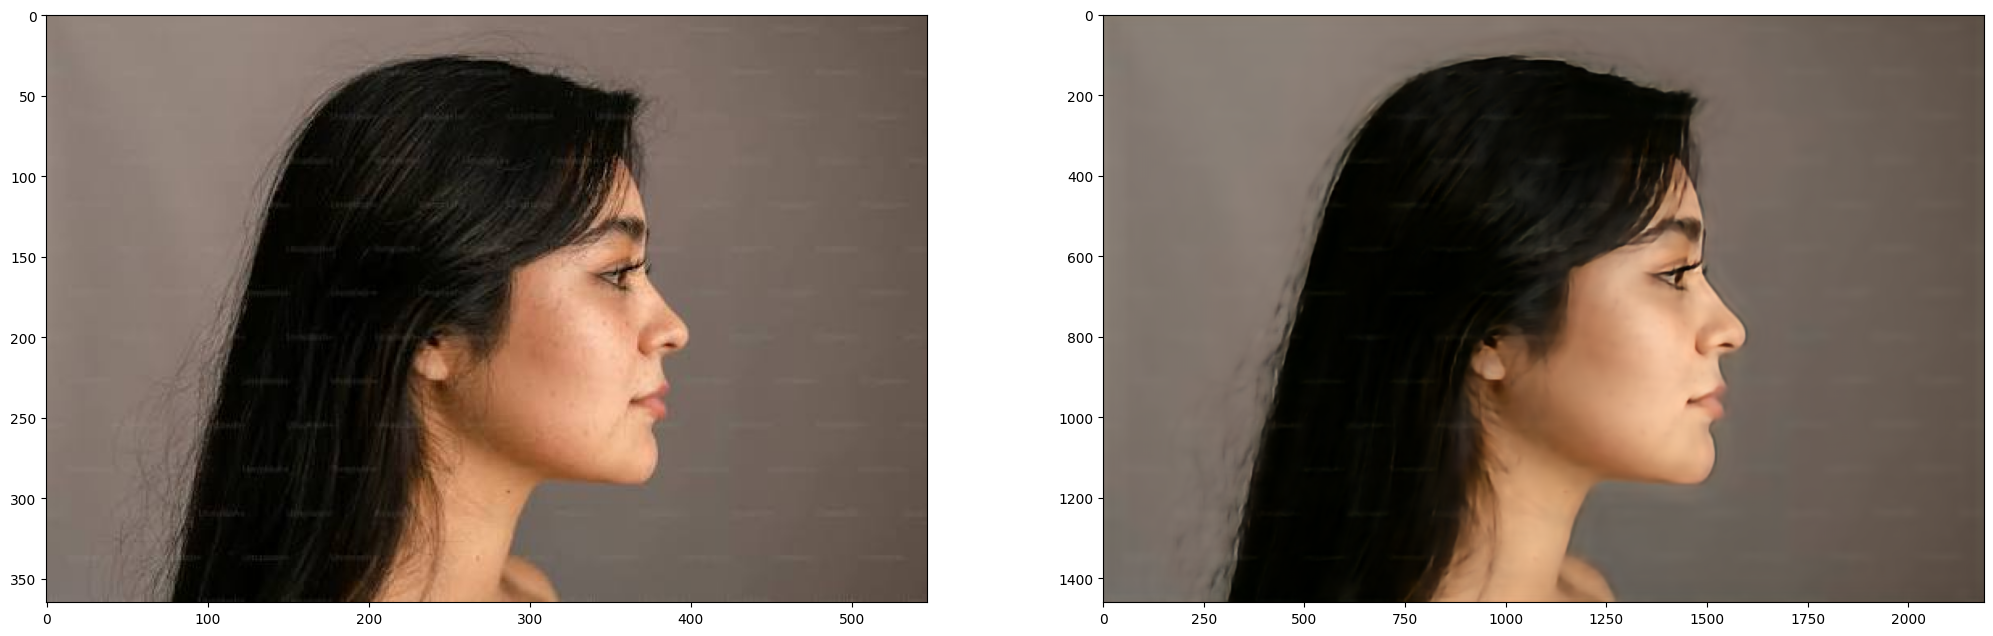

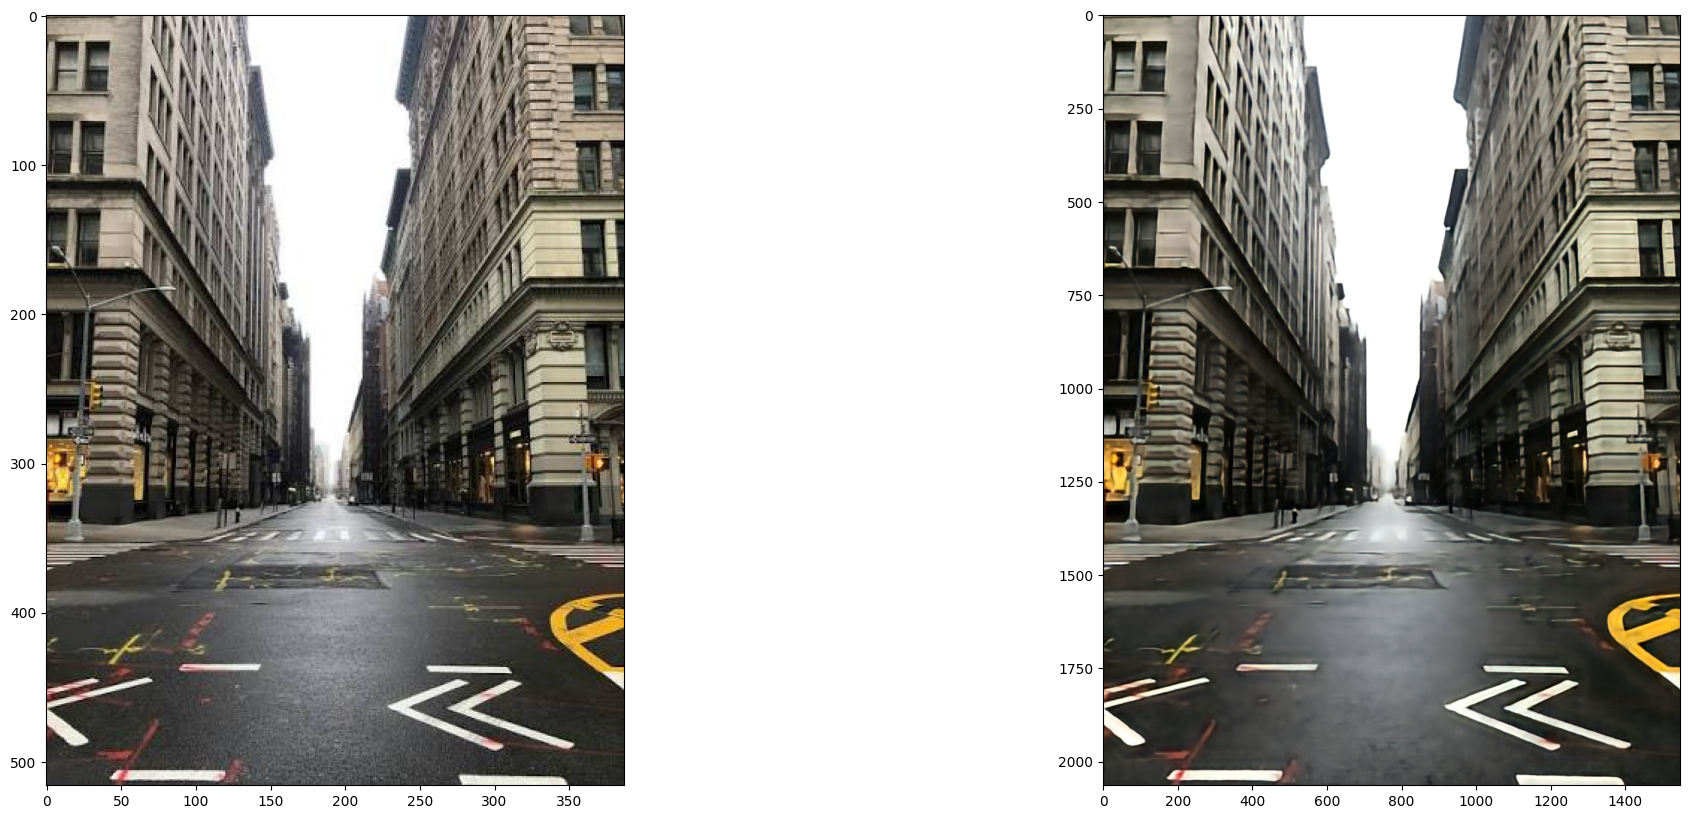

In [ ]:
plt.figure(figsize=(25, 10))
plt.subplot(121)
plt.imshow(lr_img_1)
plt.subplot(122)
plt.imshow(t1.squeeze(0).cpu().permute(1, 2, 0).detach().numpy())
plt.show()

plt.figure(figsize=(25, 10))
plt.subplot(121)
plt.imshow(lr_img_2)
plt.subplot(122)
plt.imshow(t2.squeeze(0).cpu().permute(1, 2, 0).detach().numpy())
plt.show()

Sauvegarde des résultats.

In [ ]:
vutils.save_image(t1.squeeze(0).cpu(), '/content/output1.png')
vutils.save_image(t2.squeeze(0).cpu(), '/content/output2.png')

# VI. Conclusion

Dans ce notebook 📓, nous avons entraîné un modèle Real-ESRNet en nous référant à l'article original du modèle. Nous avons utilisé des données que nous avons collectées, puis nous avons défini et appliqué la dégradation du second ordre pour créer des images de basse résolution.

Nous pouvons constater que le modèle arrive à restaurer la qualité d'une image à basse résolution même après quelques itérations. Le modèle est aussi très puissant en matière de suppression de bruit, etc. Nous avons peu de données et très peu d'itérations, d'où le résultat lisse du modèle.

Pour obtenir des résultats plus satisfaisants, nous avons encore besoin de beaucoup plus de données et d'itérations. Nous devons aussi améliorer le modèle si nous voulons obtenir des résultats encore plus convaincants. C'est pour cela que nous nous demandons quelle sera la nouvelle architecture du modèle à l'avenir.